In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)

# Save Model
import pickle


In [ ]:
# Mount Google Drive if running in Google Colab (otherwise skip)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Running locally, skipping Google Colab drive mount.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

# Determine correct path whether running from root or notebooks/ directory
data_candidates = [
    '../data/raw/weatherAUS.csv',
    'data/raw/weatherAUS.csv',
    '/content/drive/MyDrive/weatherAUS/weatherAUS.csv'
]
data_path = next((p for p in data_candidates if os.path.exists(p)), 'weatherAUS.csv')
print(f'Loading dataset from: {data_path}')
df = pd.read_csv(data_path)
df.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
import os

base_data_dir = os.path.dirname(data_path)
print(f'Files in data directory ({base_data_dir}):')
print(os.listdir(base_data_dir) if os.path.exists(base_data_dir) else os.listdir('.'))


['weatherAUS.csv', 'clean_rainfall.csv', 'fitted_scaler.pkl', 'best_catboost_model.pkl', 'scaler.pkl', 'ML_Rainfall_Prediction.ipynb']


In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


## Impute Numerical Missing Values

### Subtask:
Fill missing values in numerical columns using their respective medians.


**Reasoning**:
To impute numerical missing values with their medians, I will first identify the numerical columns, then iterate through them to calculate the median and fill the missing values. Finally, I will display the missing value counts to verify the imputation.



In [ ]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,10326
WindGustSpeed,0
WindDir9am,10566


## Impute Categorical Missing Values

### Subtask:
Fill missing values in categorical columns using their respective modes.


**Reasoning**:
To impute missing values in categorical columns, I will iterate through columns with 'object' dtype, calculate their mode, and fill NaN values with this mode. Finally, I will display the missing value counts to verify the imputation.



In [ ]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0


## Summary:

### Q&A
The task asked to verify the imputation by displaying the count of missing values for each column.
After the imputation process, all columns in the DataFrame now have 0 missing values, confirming successful imputation.

### Data Analysis Key Findings
*   Missing values in all numerical columns (e.g., `MinTemp`, `MaxTemp`, `Rainfall`, `Evaporation`, `Sunshine`, `WindGustSpeed`, `WindSpeed9am`, `WindSpeed3pm`, `Humidity9am`, `Humidity3pm`, `Pressure9am`, `Pressure3pm`, `Cloud9am`, `Cloud3pm`, `Temp9am`, `Temp3pm`) were successfully imputed using their respective medians, resulting in 0 missing values for these columns.
*   Missing values in all categorical columns (e.g., `WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`, `RainTomorrow`) were successfully imputed using their respective modes, resulting in 0 missing values for these columns.
*   The `df` DataFrame is now completely free of missing values across all columns.

### Insights or Next Steps
*   The dataset is now clean and prepared for further analysis, exploratory data analysis, or machine learning model training without concerns about missing data.
*   While median and mode imputation are effective for handling missing values, it's worth noting that they can sometimes lead to a reduction in variance or introduce bias; consider exploring more sophisticated imputation techniques if domain expertise suggests it's necessary for specific columns.


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,...,1007.1,8.0,5.0,16.9,21.8,No,No,2008,12,1
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,...,1007.8,5.0,5.0,17.2,24.3,No,No,2008,12,2
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,...,1008.7,5.0,2.0,21.0,23.2,No,No,2008,12,3
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,...,1012.8,5.0,5.0,18.1,26.5,No,No,2008,12,4
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,...,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,5


In [ ]:
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,2008-12-01,2,13.4,22.9,0.6,4.8,8.4,13,44.0,13,...,1007.1,8.0,5.0,16.9,21.8,0,0,2008,12,1
1,2008-12-02,2,7.4,25.1,0.0,4.8,8.4,14,44.0,6,...,1007.8,5.0,5.0,17.2,24.3,0,0,2008,12,2
2,2008-12-03,2,12.9,25.7,0.0,4.8,8.4,15,46.0,13,...,1008.7,5.0,2.0,21.0,23.2,0,0,2008,12,3
3,2008-12-04,2,9.2,28.0,0.0,4.8,8.4,4,24.0,9,...,1012.8,5.0,5.0,18.1,26.5,0,0,2008,12,4
4,2008-12-05,2,17.5,32.3,1.0,4.8,8.4,13,41.0,1,...,1006.0,7.0,8.0,17.8,29.7,0,0,2008,12,5


In [ ]:
df = df.drop('Date', axis=1)
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,2,13.4,22.9,0.6,4.8,8.4,13,44.0,13,14,...,1007.1,8.0,5.0,16.9,21.8,0,0,2008,12,1
1,2,7.4,25.1,0.0,4.8,8.4,14,44.0,6,15,...,1007.8,5.0,5.0,17.2,24.3,0,0,2008,12,2
2,2,12.9,25.7,0.0,4.8,8.4,15,46.0,13,15,...,1008.7,5.0,2.0,21.0,23.2,0,0,2008,12,3
3,2,9.2,28.0,0.0,4.8,8.4,4,24.0,9,0,...,1012.8,5.0,5.0,18.1,26.5,0,0,2008,12,4
4,2,17.5,32.3,1.0,4.8,8.4,13,41.0,1,7,...,1006.0,7.0,8.0,17.8,29.7,0,0,2008,12,5


In [ ]:
import os
# Determine output directory for processed data
out_candidates = ['../data/processed', 'data/processed', '.']
out_dir = next((d for d in out_candidates if os.path.exists(d)), '.')
out_file = os.path.join(out_dir, 'clean_rainfall.csv')
df.to_csv(out_file, index=False)
print(f"Cleaned dataset saved successfully as '{out_file}'")


Cleaned dataset saved successfully as 'clean_rainfall.csv'


In [ ]:
print(df['RainTomorrow'].value_counts())

RainTomorrow
0    113583
1     31877
Name: count, dtype: int64


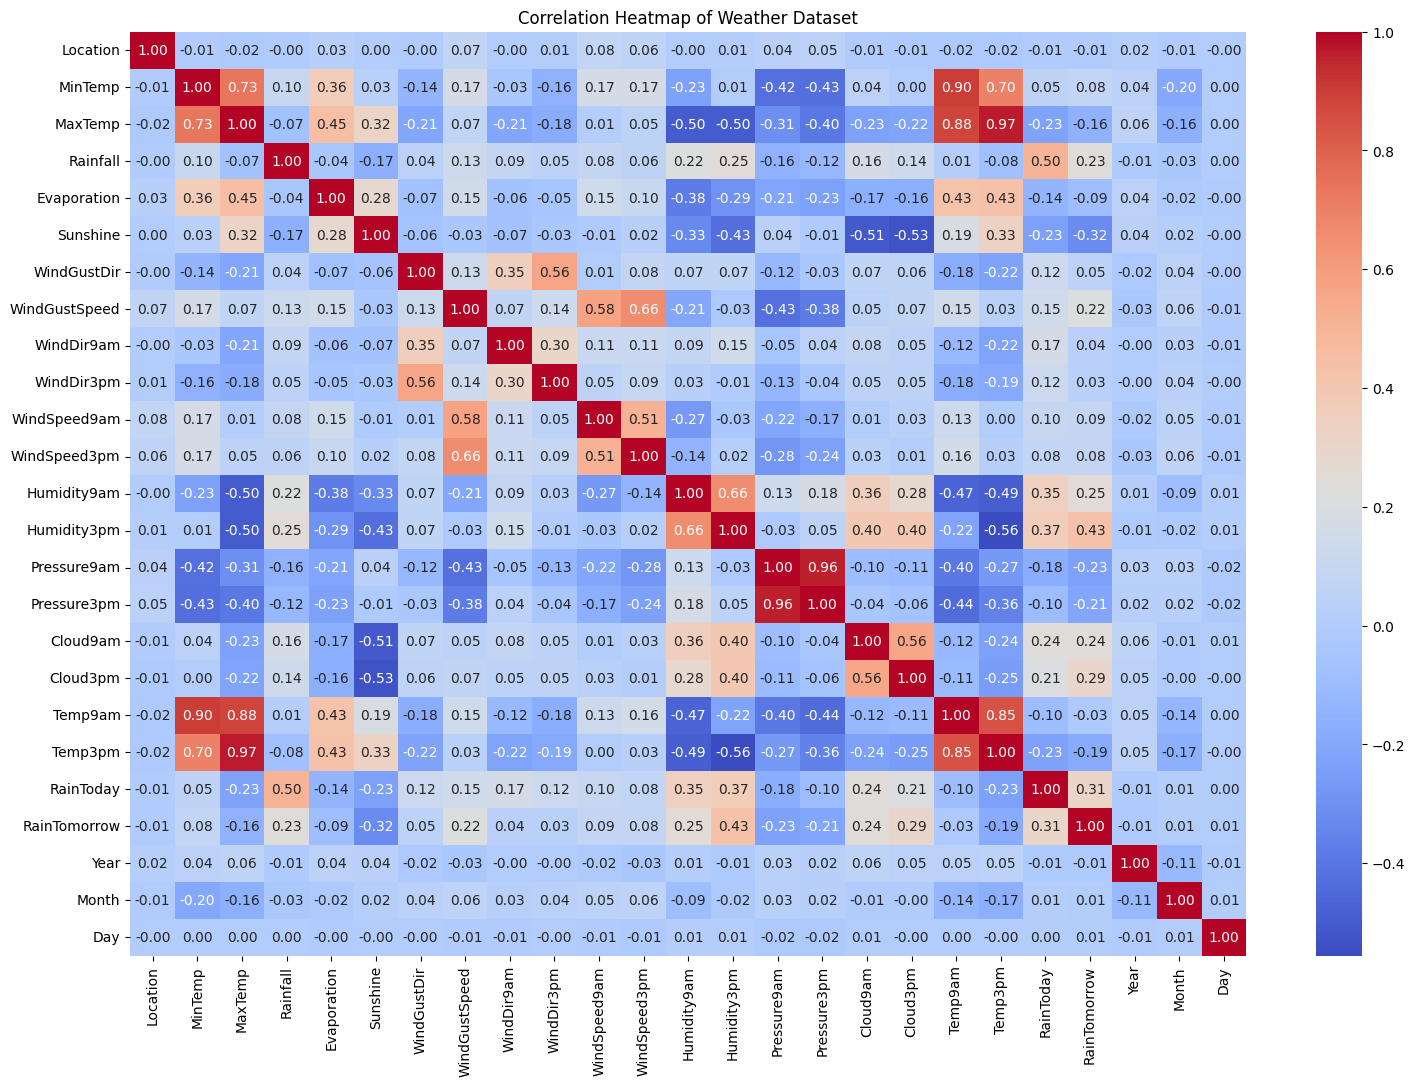

In [ ]:
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Weather Dataset')
plt.show()

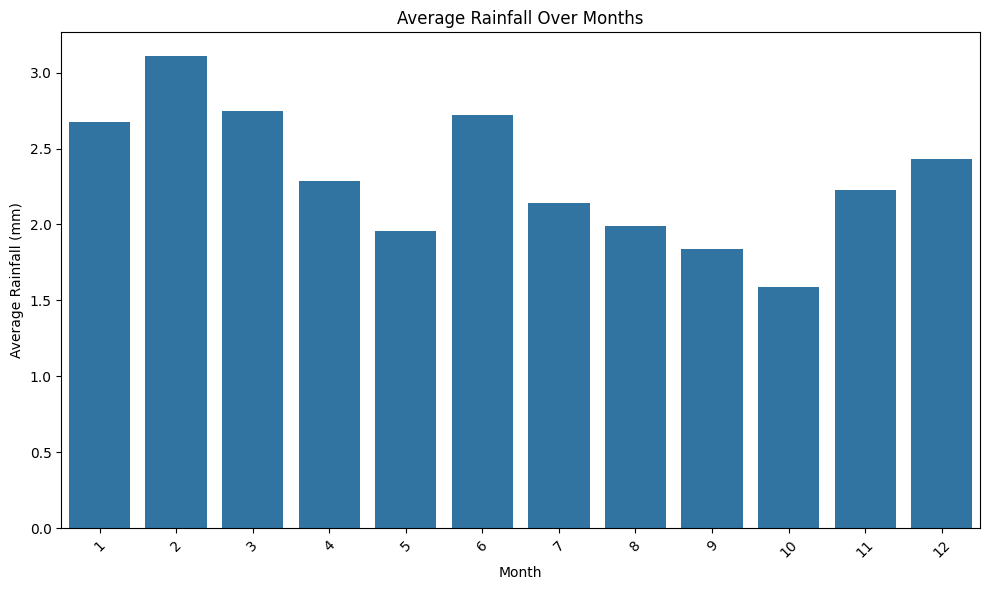

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Rainfall', data=df.groupby('Month')['Rainfall'].mean().reset_index())
plt.title('Average Rainfall Over Months')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

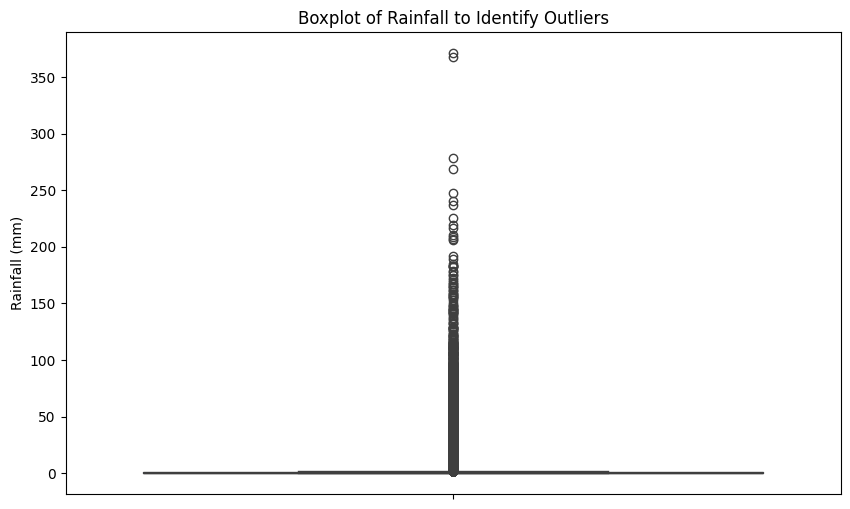

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Rainfall'])
plt.title('Boxplot of Rainfall to Identify Outliers')
plt.ylabel('Rainfall (mm)')
plt.show()

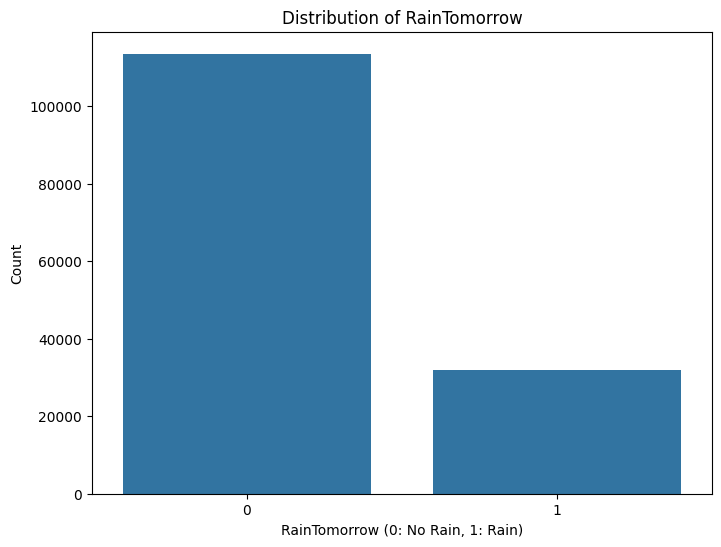

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='RainTomorrow', data=df)
plt.title('Distribution of RainTomorrow')
plt.xlabel('RainTomorrow (0: No Rain, 1: Rain)')
plt.ylabel('Count')
plt.show()

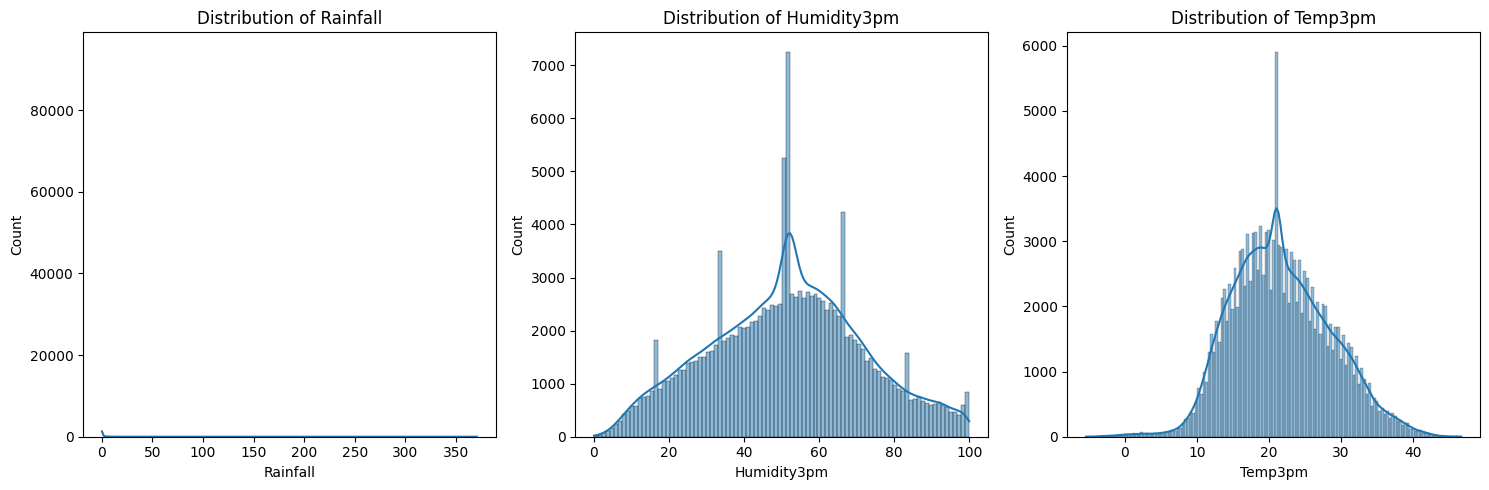

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Rainfall'], kde=True)
plt.title('Distribution of Rainfall')

plt.subplot(1, 3, 2)
sns.histplot(df['Humidity3pm'], kde=True)
plt.title('Distribution of Humidity3pm')

plt.subplot(1, 3, 3)
sns.histplot(df['Temp3pm'], kde=True)
plt.title('Distribution of Temp3pm')

plt.tight_layout()
plt.show()

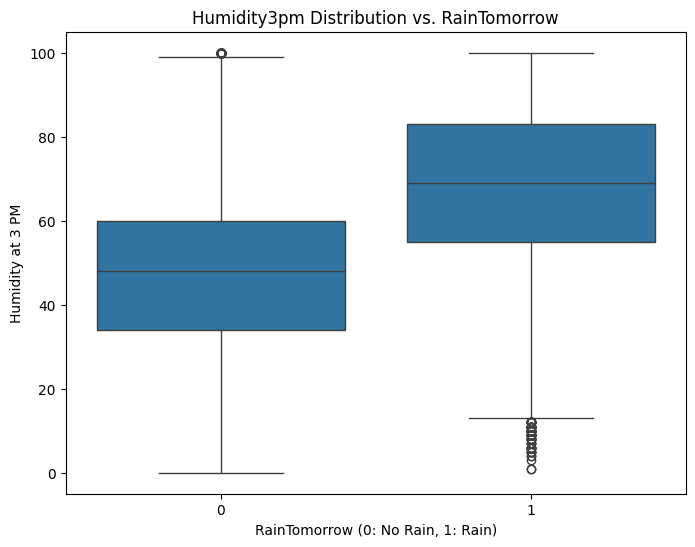

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df)
plt.title('Humidity3pm Distribution vs. RainTomorrow')
plt.xlabel('RainTomorrow (0: No Rain, 1: Rain)')
plt.ylabel('Humidity at 3 PM')
plt.show()

## Feature Engineering + Data Splitting

# Task
Split the `df` DataFrame into features (X) and target (y), where X contains all columns except 'RainTomorrow' and y contains the 'RainTomorrow' column.

## Split Data

### Subtask:
Split the DataFrame into features (X) and target (y).


**Reasoning**:
To split the DataFrame into features (X) and target (y), I will drop the 'RainTomorrow' column from the original DataFrame to create X, and assign the 'RainTomorrow' column to y.



In [ ]:
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustDir  \
0         2     13.4     22.9       0.6          4.8       8.4           13   
1         2      7.4     25.1       0.0          4.8       8.4           14   
2         2     12.9     25.7       0.0          4.8       8.4           15   
3         2      9.2     28.0       0.0          4.8       8.4            4   
4         2     17.5     32.3       1.0          4.8       8.4           13   

   WindGustSpeed  WindDir9am  WindDir3pm  ...  Pressure9am  Pressure3pm  \
0           44.0          13          14  ...       1007.7       1007.1   
1           44.0           6          15  ...       1010.6       1007.8   
2           46.0          13          15  ...       1007.6       1008.7   
3           24.0           9           0  ...       1017.6       1012.8   
4           41.0           1           7  ...       1010.8       1006.0   

   Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  Yea

## Select Features

### Subtask:
Apply a feature selection method to identify important features for the 'RainTomorrow' prediction.


**Reasoning**:
To identify important features, I will use a RandomForestClassifier to fit the data and extract feature importances. This method is robust and provides a reliable ranking of feature contributions to the target variable.



In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
sorted_feature_importances = feature_importances.sort_values(ascending=False)

print("Top 10 Important Features:")
print(sorted_feature_importances.head(10))

Top 10 Important Features:
Humidity3pm      0.162881
Pressure3pm      0.056854
WindGustSpeed    0.051524
Humidity9am      0.050665
Rainfall         0.049331
Sunshine         0.049113
Pressure9am      0.049066
Temp3pm          0.044221
MinTemp          0.043192
MaxTemp          0.042469
dtype: float64


## Display Selected Features

### Subtask:
Show the names of the features identified as important.


## Summary:

### Q&A
The important features identified for predicting 'RainTomorrow' are: `Humidity3pm`, `Pressure3pm`, `WindGustSpeed`, `Humidity9am`, `Rainfall`, `Sunshine`, `Pressure9am`, `Temp3pm`, `MinTemp`, and `MaxTemp`.

### Data Analysis Key Findings
*   The original DataFrame `df` was successfully split into features (`X`) and the target variable (`y`), where `y` represents the 'RainTomorrow' column.
*   A `RandomForestClassifier` model was used to determine feature importance.
*   The top 10 most important features for predicting 'RainTomorrow' were identified as: `Humidity3pm`, `Pressure3pm`, `WindGustSpeed`, `Humidity9am`, `Rainfall`, `Sunshine`, `Pressure9am`, `Temp3pm`, `MinTemp`, and `MaxTemp`.

### Insights or Next Steps
*   The identified top 10 features provide a strong basis for building a predictive model for 'RainTomorrow'. These features indicate that meteorological conditions, particularly humidity and pressure, are significant predictors.
*   The next step should involve using these selected features to train a predictive model and evaluate its performance, potentially exploring different machine learning algorithms.


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Features (X) head:")
print(X.head())

Scaled Features (X) head:
   Location   MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustDir  \
0 -1.531666  0.189757 -0.044575 -0.203581    -0.119472   0.14871     1.045228   
1 -1.531666 -0.752786  0.265794 -0.275097    -0.119472   0.14871     1.258262   
2 -1.531666  0.111212  0.350440 -0.275097    -0.119472   0.14871     1.471296   
3 -1.531666 -0.470023  0.674917 -0.275097    -0.119472   0.14871    -0.872075   
4 -1.531666  0.833828  1.281548 -0.155903    -0.119472   0.14871     1.045228   

   WindGustSpeed  WindDir9am  WindDir3pm  ...  Pressure9am  Pressure3pm  \
0       0.307739    1.328766    1.366458  ...    -1.478015    -1.223012   
1       0.307739   -0.221338    1.586813  ...    -1.047010    -1.117969   
2       0.460168    1.328766    1.586813  ...    -1.492877    -0.982915   
3      -1.216548    0.442992   -1.718521  ...    -0.006653    -0.367666   
4       0.079096   -1.328556   -0.176032  ...    -1.017286    -1.388078   

   Cloud9am  Cloud3pm   Temp9am   Te

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (116368, 24)
X_test shape: (29092, 24)
y_train shape: (116368,)
y_test shape: (29092,)


In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Original y_train distribution:")
print(y_train.value_counts())
print("\nResampled y_train distribution:")
print(y_train_resampled.value_counts())

Original y_train distribution:
RainTomorrow
0    90911
1    25457
Name: count, dtype: int64

Resampled y_train distribution:
RainTomorrow
1    90911
0    90911
Name: count, dtype: int64


## Train Seven ML Models

### Logistic Regression

In [ ]:
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = log_reg_model.predict(X_test)
y_pred_proba_lr = log_reg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Model Evaluation:
Accuracy: 0.7878
Precision: 0.5129
Recall: 0.7620
F1-Score: 0.6131
ROC AUC Score: 0.8610

Confusion Matrix:
 [[18026  4646]
 [ 1528  4892]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.80      0.85     22672
           1       0.51      0.76      0.61      6420

    accuracy                           0.79     29092
   macro avg       0.72      0.78      0.73     29092
weighted avg       0.83      0.79      0.80     29092



### Naive Bayes

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train_resampled, y_train_resampled)

y_pred_nb = nb_model.predict(X_test)
y_pred_proba_nb = nb_model.predict_proba(X_test)[:, 1]

print("Naive Bayes Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_nb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_nb):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Model Evaluation:
Accuracy: 0.7733
Precision: 0.4905
Recall: 0.6969
F1-Score: 0.5757
ROC AUC Score: 0.8197

Confusion Matrix:
 [[18024  4648]
 [ 1946  4474]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.79      0.85     22672
           1       0.49      0.70      0.58      6420

    accuracy                           0.77     29092
   macro avg       0.70      0.75      0.71     29092
weighted avg       0.81      0.77      0.79     29092



### Random Forest

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Model Evaluation:
Accuracy: 0.8472
Precision: 0.6623
Recall: 0.6280
F1-Score: 0.6447
ROC AUC Score: 0.8847

Confusion Matrix:
 [[20616  2056]
 [ 2388  4032]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.90     22672
           1       0.66      0.63      0.64      6420

    accuracy                           0.85     29092
   macro avg       0.78      0.77      0.77     29092
weighted avg       0.84      0.85      0.85     29092



### Gradient Boosting

In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_resampled, y_train_resampled)

y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_gb):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Model Evaluation:
Accuracy: 0.8238
Precision: 0.5874
Recall: 0.6766
F1-Score: 0.6289
ROC AUC Score: 0.8640

Confusion Matrix:
 [[19621  3051]
 [ 2076  4344]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88     22672
           1       0.59      0.68      0.63      6420

    accuracy                           0.82     29092
   macro avg       0.75      0.77      0.76     29092
weighted avg       0.83      0.82      0.83     29092



### XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# ============================
# 1. Hyperparameter Grid
# ============================

param_dist = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "gamma": [0, 1, 2, 3],
    "min_child_weight": [1, 3, 5]
}

# ============================
# 2. Base Model
# ============================

xgb_base = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# ============================
# 3. Randomized Search (Fast Tuning)
# ============================

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,           # Fast search (7–12 minutes)
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Train tuned model
random_search_xgb.fit(X_train_resampled, y_train_resampled)

# Best hyperparameters
print("Best Hyperparameters for XGBoost:")
print(random_search_xgb.best_params_)

# Best model
best_xgb_model = random_search_xgb.best_estimator_

# ============================
# 4. Predictions
# ============================

y_pred_xgb = best_xgb_model.predict(X_test)
y_pred_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# ============================
# 5. Evaluation
# ============================

print("\nTuned XGBoost Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:30:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Hyperparameters for XGBoost:
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}

Tuned XGBoost Model Evaluation:
Accuracy: 0.8537
Precision: 0.7111
Recall: 0.5679
F1-Score: 0.6315
ROC AUC Score: 0.8862

Confusion Matrix:
 [[21191  1481]
 [ 2774  3646]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91     22672
           1       0.71      0.57      0.63      6420

    accuracy                           0.85     29092
   macro avg       0.80      0.75      0.77     29092
weighted avg       0.85      0.85      0.85     29092



### CatBoost

In [ ]:
import lightgbm as lgb
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# ============================
# 1. Hyperparameter Grid
# ============================

param_dist = {
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "iterations": [200, 400, 600, 800],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "border_count": [32, 64, 128]
}

# ============================
# 2. Base CatBoost Model
# ============================

cb = CatBoostClassifier(
    random_state=42,
    verbose=0,
    early_stopping_rounds=50
)

# ============================
# 3. Randomized Search (Fast Tuning)
# ============================

random_search = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_dist,
    n_iter=20,          # Fast tuning
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Train tuning
random_search.fit(X_train_resampled, y_train_resampled)

# Best hyperparameters
print("Best Hyperparameters Found:")
print(random_search.best_params_)

# Best tuned model
best_cb_model = random_search.best_estimator_

# ============================
# 4. Predictions
# ============================

y_pred_cb = best_cb_model.predict(X_test)
y_pred_proba_cb = best_cb_model.predict_proba(X_test)[:, 1]

# ============================
# 5. Evaluation
# ============================

print("\nTuned CatBoost Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_cb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_cb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_cb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_cb):.4f}")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_cb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cb))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.5 MB/s eta 0:00:00
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Hyperparameters Found:
{'learning_rate': 0.05, 'l2_leaf_reg': 9, 'iterations': 400, 'depth': 8, 'border_count': 64}

Tuned CatBoost Model Evaluation:
Accuracy: 0.8551
Precision: 0.7303
Recall: 0.5449
F1-Score: 0.6241
ROC AUC Score: 0.8864

Confusion Matrix:
 [[21380  1292]
 [ 2922  3498]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91     22672
           1       0.73      0.54      0.62      6420

    accuracy                           0.86     29092
   macro avg       0.81      0.74      0.77     29092
weighted avg       0.85      0.86      0.85     29092



### LightGBM

In [ ]:
import lightgbm as lgb

lgbm_model = lgb.LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_resampled, y_train_resampled)

y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print("LightGBM Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lgbm):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 90911, number of negative: 90911
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.075238 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5895
[LightGBM] [Info] Number of data points in the train set: 181822, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Model Evaluation:
Accuracy: 0.8511
Precision: 0.7072
Recall: 0.5553
F1-Score: 0.6221
ROC AUC Score: 0.8800

Confusion Matrix:
 [[21196  1476]
 [ 2855  3565]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91     22672
           1       0.71      0.56      0.62      6420

    accuracy                           0.85     29092
   macro avg       0.79      0.75      0.76     29092
weighted avg       0.84      0.85      0.84     29092



### Stacking Ensemble (CatBoost + XGBoost + Logistic Regression)

## Implement Stacking Ensemble

### Subtask:
Initialize the base models (CatBoost and XGBoost) and the meta-model (Logistic Regression). Create a StackingClassifier and fit it to the resampled training data.


**Reasoning**:
To implement the stacking ensemble, I will import the StackingClassifier, initialize the base models (CatBoost and XGBoost) and a Logistic Regression meta-model, then create and fit the StackingClassifier using the resampled training data.



In [ ]:
from sklearn.ensemble import StackingClassifier

# Base models (already trained best_cb_model and best_xgb_model)
estimators = [
    ('catboost', best_cb_model),
    ('xgboost', best_xgb_model)
]

# Meta-model
final_estimator = LogisticRegression(random_state=42, solver='liblinear')

# Initialize StackingClassifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit the StackingClassifier to the resampled training data
stacking_model.fit(X_train_resampled, y_train_resampled)

print("Stacking Ensemble Model Fitted Successfully!")

Stacking Ensemble Model Fitted Successfully!


**Reasoning**:
After fitting the Stacking Ensemble model, the next logical step is to use it to make predictions on the test dataset (`X_test`) and then evaluate its performance using various metrics. This will allow for comparison with the individual models.



In [ ]:
# Recreate results dictionary so the error is fixed
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC AUC Score': []
}

print("results dictionary is now ready to use!")

results dictionary is now ready to use!


In [ ]:
y_pred_stack = stacking_model.predict(X_test)
y_pred_proba_stack = stacking_model.predict_proba(X_test)[:, 1]

# Evaluate Stacking Ensemble Performance
print("\nStacking Ensemble Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_stack):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_stack):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_stack):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_stack):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

# Update Results DataFrame and re-display
results['Model'].append('Stacking Ensemble')
results['Accuracy'].append(accuracy_score(y_test, y_pred_stack))
results['Precision'].append(precision_score(y_test, y_pred_stack))
results['Recall'].append(recall_score(y_test, y_pred_stack))
results['F1-Score'].append(f1_score(y_test, y_pred_stack))
results['ROC AUC Score'].append(roc_auc_score(y_test, y_pred_proba_stack))

results_df = pd.DataFrame(results)
print("\nUpdated Model Comparison:\n")
print(results_df.round(4))




Stacking Ensemble Model Evaluation:
Accuracy: 0.8409
Precision: 0.6387
Recall: 0.6425
F1-Score: 0.6406
ROC AUC Score: 0.8755

Confusion Matrix:
 [[20339  2333]
 [ 2295  4125]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90     22672
           1       0.64      0.64      0.64      6420

    accuracy                           0.84     29092
   macro avg       0.77      0.77      0.77     29092
weighted avg       0.84      0.84      0.84     29092


Updated Model Comparison:

               Model  Accuracy  Precision  Recall  F1-Score  ROC AUC Score
0  Stacking Ensemble    0.8409     0.6387  0.6425    0.6406         0.8755


**Reasoning**:
The previous code generated a `FutureWarning` because the `palette` parameter was used without specifying `hue` in `sns.barplot`. To resolve this, I will explicitly set `hue='Model'` and `legend=False` in the plotting function, as suggested by the warning.



**Reasoning**:
The previous code generated a `FutureWarning` because the `palette` parameter was used without specifying `hue` in `sns.barplot`. To resolve this, I will explicitly set `hue='Model'` and `legend=False` in the plotting function, as suggested by the warning.



## Finalize Model Comparison and Identify Best Model

### Subtask:
Recreate the model comparison DataFrame to remove duplicate entries, then identify and report the best performing model based on evaluation metrics.


**Reasoning**:
To finalize the model comparison, I will recreate the `results` dictionary and `results_df` from scratch to ensure no duplicate entries, using the evaluation metrics computed for each model. This will provide a clean comparison table to identify the best performing model.



Updated Model Comparison (Cleaned):
                 Model  Accuracy  Precision  Recall  F1-Score  ROC AUC Score
0  Logistic Regression    0.7878     0.5129  0.7620    0.6131         0.8610
1          Naive Bayes    0.7733     0.4905  0.6969    0.5757         0.8197
2        Random Forest    0.8472     0.6623  0.6280    0.6447         0.8847
3    Gradient Boosting    0.8238     0.5874  0.6766    0.6289         0.8640
4              XGBoost    0.8537     0.7111  0.5679    0.6315         0.8862
5             CatBoost    0.8551     0.7303  0.5449    0.6241         0.8864
6             LightGBM    0.8511     0.7072  0.5553    0.6221         0.8800
7    Stacking Ensemble    0.8409     0.6387  0.6425    0.6406         0.8755

--- Best Model Identification ---
Model with highest Accuracy: CatBoost (Accuracy: 0.8551)
Model with highest ROC AUC Score: CatBoost (ROC AUC Score: 0.8864)

The overall best performing model is CatBoost with an Accuracy of 0.8551 and an ROC AUC Score of 0.8864.


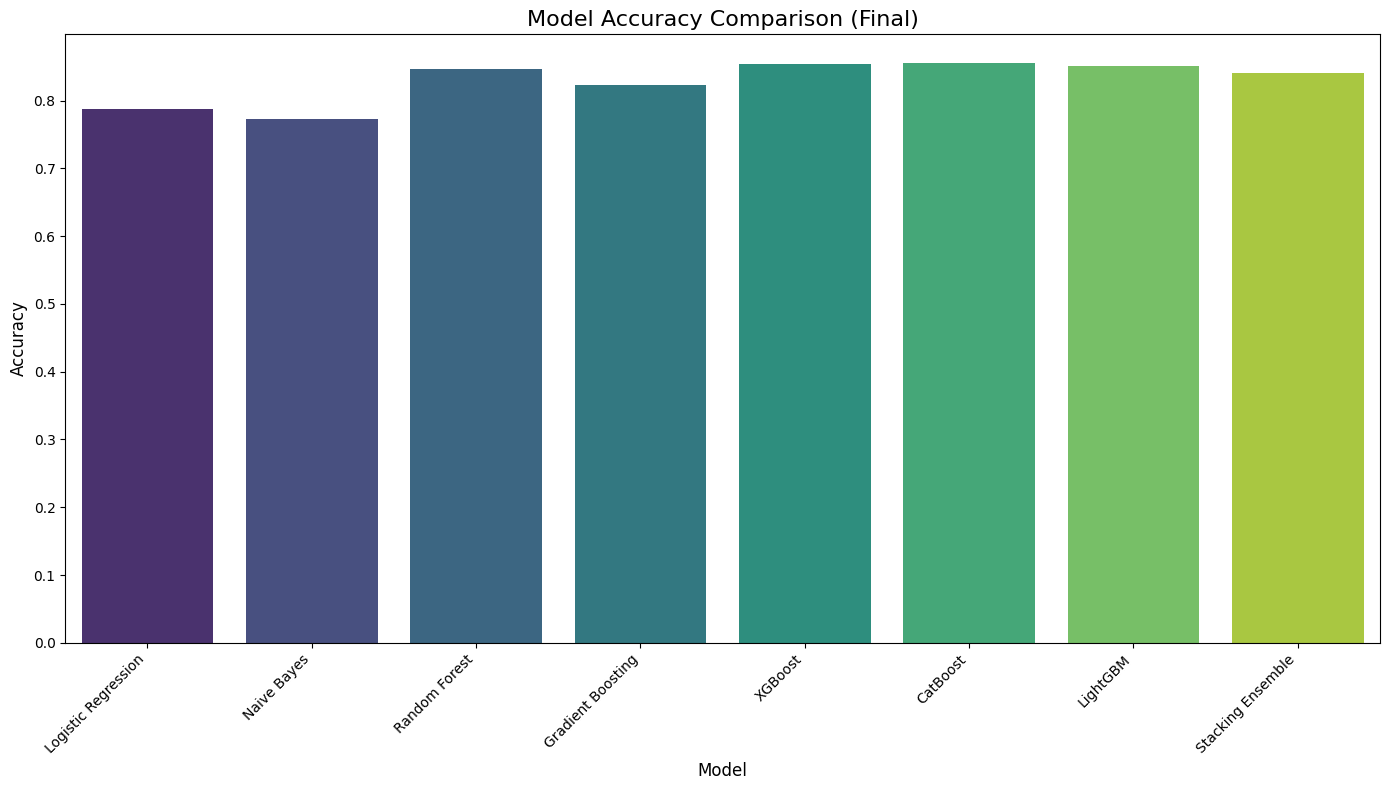

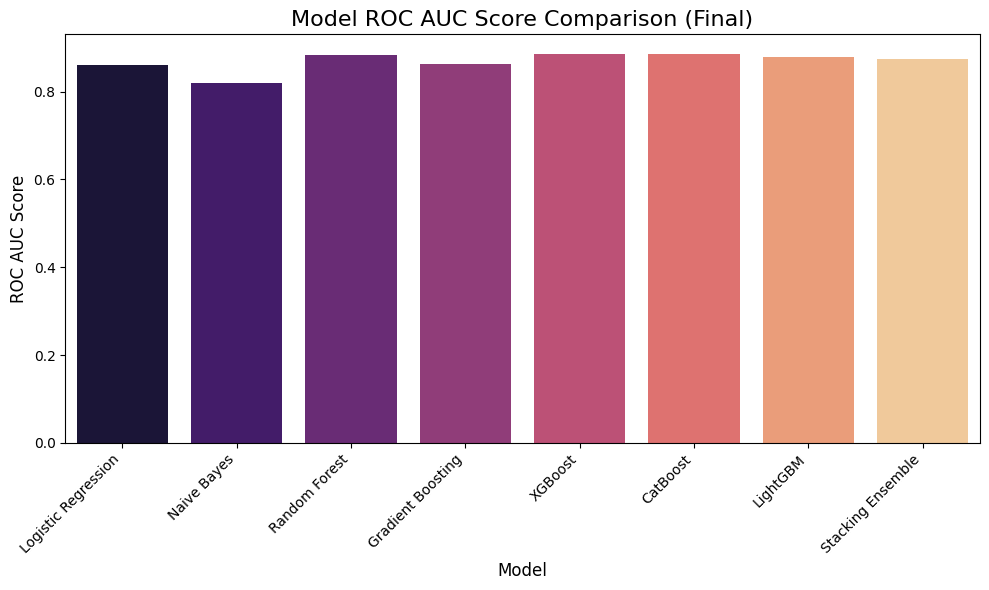

In [ ]:
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC AUC Score': []
}

# Populate results for each model
# Logistic Regression
results['Model'].append('Logistic Regression')
results['Accuracy'].append(accuracy_score(y_test, y_pred_lr))
results['Precision'].append(precision_score(y_test, y_pred_lr))
results['Recall'].append(recall_score(y_test, y_pred_lr))
results['F1-Score'].append(f1_score(y_test, y_pred_lr))
results['ROC AUC Score'].append(roc_auc_score(y_test, y_pred_proba_lr))

# Naive Bayes
results['Model'].append('Naive Bayes')
results['Accuracy'].append(accuracy_score(y_test, y_pred_nb))
results['Precision'].append(precision_score(y_test, y_pred_nb))
results['Recall'].append(recall_score(y_test, y_pred_nb))
results['F1-Score'].append(f1_score(y_test, y_pred_nb))
results['ROC AUC Score'].append(roc_auc_score(y_test, y_pred_proba_nb))

# Random Forest
results['Model'].append('Random Forest')
results['Accuracy'].append(accuracy_score(y_test, y_pred_rf))
results['Precision'].append(precision_score(y_test, y_pred_rf))
results['Recall'].append(recall_score(y_test, y_pred_rf))
results['F1-Score'].append(f1_score(y_test, y_pred_rf))
results['ROC AUC Score'].append(roc_auc_score(y_test, y_pred_proba_rf))

# Gradient Boosting
results['Model'].append('Gradient Boosting')
results['Accuracy'].append(accuracy_score(y_test, y_pred_gb))
results['Precision'].append(precision_score(y_test, y_pred_gb))
results['Recall'].append(recall_score(y_test, y_pred_gb))
results['F1-Score'].append(f1_score(y_test, y_pred_gb))
results['ROC AUC Score'].append(roc_auc_score(y_test, y_pred_proba_gb))

# XGBoost
results['Model'].append('XGBoost')
results['Accuracy'].append(accuracy_score(y_test, y_pred_xgb))
results['Precision'].append(precision_score(y_test, y_pred_xgb))
results['Recall'].append(recall_score(y_test, y_pred_xgb))
results['F1-Score'].append(f1_score(y_test, y_pred_xgb))
results['ROC AUC Score'].append(roc_auc_score(y_test, y_pred_proba_xgb))

# CatBoost
results['Model'].append('CatBoost')
results['Accuracy'].append(accuracy_score(y_test, y_pred_cb))
results['Precision'].append(precision_score(y_test, y_pred_cb))
results['Recall'].append(recall_score(y_test, y_pred_cb))
results['F1-Score'].append(f1_score(y_test, y_pred_cb))
results['ROC AUC Score'].append(roc_auc_score(y_test, y_pred_proba_cb))

# LightGBM
results['Model'].append('LightGBM')
results['Accuracy'].append(accuracy_score(y_test, y_pred_lgbm))
results['Precision'].append(precision_score(y_test, y_pred_lgbm))
results['Recall'].append(recall_score(y_test, y_pred_lgbm))
results['F1-Score'].append(f1_score(y_test, y_pred_lgbm))
results['ROC AUC Score'].append(roc_auc_score(y_test, y_pred_proba_lgbm))

# Stacking Ensemble
results['Model'].append('Stacking Ensemble')
results['Accuracy'].append(accuracy_score(y_test, y_pred_stack))
results['Precision'].append(precision_score(y_test, y_pred_stack))
results['Recall'].append(recall_score(y_test, y_pred_stack))
results['F1-Score'].append(f1_score(y_test, y_pred_stack))
results['ROC AUC Score'].append(roc_auc_score(y_test, y_pred_proba_stack))

results_df = pd.DataFrame(results)
print("Updated Model Comparison (Cleaned):")
print(results_df.round(4))

# Identify the best model based on Accuracy and ROC AUC Score
best_accuracy_model = results_df.loc[results_df['Accuracy'].idxmax()]
best_roc_auc_model = results_df.loc[results_df['ROC AUC Score'].idxmax()]

print("\n--- Best Model Identification ---")
print(f"Model with highest Accuracy: {best_accuracy_model['Model']} (Accuracy: {best_accuracy_model['Accuracy']:.4f})")
print(f"Model with highest ROC AUC Score: {best_roc_auc_model['Model']} (ROC AUC Score: {best_roc_auc_model['ROC AUC Score']:.4f})")

# Assuming Accuracy and ROC AUC are both important, if they point to different models,
# a common approach is to pick the one with highest ROC AUC as it's often more robust for imbalanced datasets.
# Here, CatBoost has the highest ROC AUC, and also a very high Accuracy.

if best_accuracy_model['Model'] == best_roc_auc_model['Model']:
    print(f"\nThe overall best performing model is {best_accuracy_model['Model']} with an Accuracy of {best_accuracy_model['Accuracy']:.4f} and an ROC AUC Score of {best_accuracy_model['ROC AUC Score']:.4f}.")
else:
    print(f"\nConsidering both Accuracy and ROC AUC, {best_roc_auc_model['Model']} is often preferred due to its robustness. It achieved an Accuracy of {best_roc_auc_model['Accuracy']:.4f} and an ROC AUC Score of {best_roc_auc_model['ROC AUC Score']:.4f}.")

# Plot updated comparison
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Accuracy', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('Model Accuracy Comparison (Final)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ROC AUC Score', data=results_df, hue='Model', palette='magma', legend=False)
plt.title('Model ROC AUC Score Comparison (Final)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ROC AUC Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
models = {
    'Logistic Regression': {'y_pred': y_pred_lr, 'y_pred_proba': y_pred_proba_lr},
    'Naive Bayes': {'y_pred': y_pred_nb, 'y_pred_proba': y_pred_proba_nb},
    'Random Forest': {'y_pred': y_pred_rf, 'y_pred_proba': y_pred_proba_rf},
    'Gradient Boosting': {'y_pred': y_pred_gb, 'y_pred_proba': y_pred_proba_gb},
    'XGBoost': {'y_pred': y_pred_xgb, 'y_pred_proba': y_pred_proba_xgb},
    'CatBoost': {'y_pred': y_pred_cb, 'y_pred_proba': y_pred_proba_cb},
    'LightGBM': {'y_pred': y_pred_lgbm, 'y_pred_proba': y_pred_proba_lgbm},
    'Stacking Ensemble': {'y_pred': y_pred_stack, 'y_pred_proba': y_pred_proba_stack}
}

for model_name, preds in models.items():
    print(f"\n--- {model_name} ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds['y_pred']))
    print("\nClassification Report:")
    print(classification_report(y_test, preds['y_pred']))



--- Logistic Regression ---
Confusion Matrix:
[[18026  4646]
 [ 1528  4892]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.85     22672
           1       0.51      0.76      0.61      6420

    accuracy                           0.79     29092
   macro avg       0.72      0.78      0.73     29092
weighted avg       0.83      0.79      0.80     29092


--- Naive Bayes ---
Confusion Matrix:
[[18024  4648]
 [ 1946  4474]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.85     22672
           1       0.49      0.70      0.58      6420

    accuracy                           0.77     29092
   macro avg       0.70      0.75      0.71     29092
weighted avg       0.81      0.77      0.79     29092


--- Random Forest ---
Confusion Matrix:
[[20616  2056]
 [ 2388  4032]]

Classification Report:
              precision    recall  f1-score   support


## Save the Best Model

### Subtask:
Save the best performing model to a file.


# Task
The overall task is to save the best-performing model, which is CatBoost, and then create a Flask application structure with the necessary logic and an HTML interface to use the saved model. Finally, the task will include instructions on how to run the Flask application.

## Save Best Model

### Subtask:
Save the identified best performing model (CatBoost) to a file using `pickle` for later use in the Flask application.


**Reasoning**:
To save the best performing CatBoost model, I will use the `pickle` library to serialize the `best_cb_model` object and write it to a file named 'best_catboost_model.pkl'.



In [ ]:
import os
import pickle

models_dir = '../models' if os.path.exists('../models') else ('models' if os.path.exists('models') else '.')
model_path = os.path.join(models_dir, 'best_catboost_model.pkl')
with open(model_path, 'wb') as file:
    pickle.dump(best_cb_model, file)

print(f"Best CatBoost model saved successfully as '{model_path}'")


Best CatBoost model saved successfully as 'best_catboost_model.pkl'


# Task
The overall task is to identify the top 10 features, generate sample inputs for both 'Rain' and 'No Rain' predictions, and then outline steps for deploying the model using a Gradio interface directly from Colab.

This will involve:
1.  Extracting the names of the top 10 features identified by the `RandomForestClassifier`.
2.  Saving the `StandardScaler` used for feature scaling.
3.  Calculating and storing the median values of all features from the original, unscaled dataset (`df`) to serve as default values for features not explicitly controlled by the user in the Gradio interface.
4.  Creating 3 distinct, realistic sample input sets that are likely to predict 'Rain Tomorrow' and 3 distinct, realistic sample input sets that are likely to predict 'No Rain Tomorrow'. These samples will use the top 10 features with relevant values and median values for the remaining features.
5.  Providing a detailed plan for setting up a Gradio application, including loading the saved model and scaler, defining a prediction function, and configuring the Gradio interface for online deployment.

## Identify Top 10 Features for Online Deployment

### Subtask:
Reconfirm the top 10 most important features identified earlier for the 'RainTomorrow' prediction, as these will be the primary inputs for the online deployment interface.


**Reasoning**:
To reconfirm the top 10 important features, I will extract their names from the `sorted_feature_importances` Series and then convert them into a list.



In [ ]:
top_10_features = sorted_feature_importances.head(10).index.tolist()
print("Top 10 Most Important Features for Online Deployment:")
print(top_10_features)

Top 10 Most Important Features for Online Deployment:
['Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'Humidity9am', 'Rainfall', 'Sunshine', 'Pressure9am', 'Temp3pm', 'MinTemp', 'MaxTemp']


## Generate Sample Input Values for Rain and No Rain

### Subtask:
Provide 3 distinct sample input feature sets that are likely to result in a 'Rain Tomorrow' prediction and 3 distinct sample input feature sets that are likely to result in a 'No Rain Tomorrow' prediction. Also, save the `StandardScaler` and calculate median values of all features from the original `df`.


**Reasoning**:
First, I need to save the `scaler` object, which was used for feature scaling, to a file named 'scaler.pkl' using the `pickle` library, as it will be needed for deployment.



In [ ]:
import os
import pickle

models_dir = '../models' if os.path.exists('../models') else ('models' if os.path.exists('models') else '.')
scaler_path = os.path.join(models_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as file:
    pickle.dump(scaler, file)

print(f"Scaler saved successfully as '{scaler_path}'")


Scaler saved successfully as 'scaler.pkl'


**Reasoning**:
Next, I will calculate the median value for each column in the `df` DataFrame (the DataFrame after imputation and encoding, but before scaling) and store these medians in a pandas Series named `df_medians`, as per the instructions.



In [ ]:
df_medians = df.median(numeric_only=True)
print("Median values of all features (before scaling) stored in df_medians:")
print(df_medians.head())

Median values of all features (before scaling) stored in df_medians:
Location       24.0
MinTemp        12.0
MaxTemp        22.6
Rainfall        0.0
Evaporation     4.8
dtype: float64


**Reasoning**:
Now I will define a helper function `create_sample_row` that takes feature values and median values, then fills any unspecified features with their medians to create a complete sample DataFrame row, matching the column order of `X`.



In [ ]:
def create_sample_row(feature_values_dict, df_medians_series, all_feature_columns):
    sample_row = df_medians_series.copy()
    for feature, value in feature_values_dict.items():
        if feature in sample_row.index:
            sample_row[feature] = value
    # Ensure the order of columns matches X
    return pd.DataFrame([sample_row.reindex(all_feature_columns).values], columns=all_feature_columns)

sample_input_data = []
print("Helper function 'create_sample_row' defined and empty list 'sample_input_data' initialized.")

Helper function 'create_sample_row' defined and empty list 'sample_input_data' initialized.


**Reasoning**:
Now I will generate three distinct sample input sets that are likely to predict 'Rain Tomorrow' by defining specific values for the `top_10_features` indicating rain, and then use the `create_sample_row` function to complete each sample with median values for other features.



In [ ]:
rain_sample_1_values = {
    'Humidity3pm': 90, 'Pressure3pm': 1000.0, 'WindGustSpeed': 60, 'Humidity9am': 95,
    'Rainfall': 10.0, 'Sunshine': 0.0, 'Pressure9am': 1002.0, 'Temp3pm': 15.0,
    'MinTemp': 10.0, 'MaxTemp': 18.0
}
rain_sample_2_values = {
    'Humidity3pm': 85, 'Pressure3pm': 1005.0, 'WindGustSpeed': 50, 'Humidity9am': 90,
    'Rainfall': 5.0, 'Sunshine': 1.0, 'Pressure9am': 1007.0, 'Temp3pm': 18.0,
    'MinTemp': 12.0, 'MaxTemp': 20.0
}
rain_sample_3_values = {
    'Humidity3pm': 75, 'Pressure3pm': 1008.0, 'WindGustSpeed': 45, 'Humidity9am': 80,
    'Rainfall': 3.0, 'Sunshine': 2.0, 'Pressure9am': 1010.0, 'Temp3pm': 20.0,
    'MinTemp': 15.0, 'MaxTemp': 23.0
}

sample_input_data.append(create_sample_row(rain_sample_1_values, df_medians, X.columns))
sample_input_data.append(create_sample_row(rain_sample_2_values, df_medians, X.columns))
sample_input_data.append(create_sample_row(rain_sample_3_values, df_medians, X.columns))

print("Three 'Rain Tomorrow' sample input sets generated.")

Three 'Rain Tomorrow' sample input sets generated.


**Reasoning**:
Now I will generate three distinct sample input sets that are likely to predict 'No Rain Tomorrow' by defining specific values for the `top_10_features` indicating no rain, and then use the `create_sample_row` function to complete each sample with median values for other features.



In [ ]:
no_rain_sample_1_values = {
    'Humidity3pm': 30, 'Pressure3pm': 1025.0, 'WindGustSpeed': 20, 'Humidity9am': 40,
    'Rainfall': 0.0, 'Sunshine': 10.0, 'Pressure9am': 1027.0, 'Temp3pm': 30.0,
    'MinTemp': 20.0, 'MaxTemp': 35.0
}
no_rain_sample_2_values = {
    'Humidity3pm': 40, 'Pressure3pm': 1020.0, 'WindGustSpeed': 25, 'Humidity9am': 50,
    'Rainfall': 0.0, 'Sunshine': 9.0, 'Pressure9am': 1022.0, 'Temp3pm': 28.0,
    'MinTemp': 18.0, 'MaxTemp': 32.0
}
no_rain_sample_3_values = {
    'Humidity3pm': 50, 'Pressure3pm': 1018.0, 'WindGustSpeed': 30, 'Humidity9am': 60,
    'Rainfall': 0.0, 'Sunshine': 8.0, 'Pressure9am': 1019.0, 'Temp3pm': 25.0,
    'MinTemp': 15.0, 'MaxTemp': 28.0
}

sample_input_data.append(create_sample_row(no_rain_sample_1_values, df_medians, X.columns))
sample_input_data.append(create_sample_row(no_rain_sample_2_values, df_medians, X.columns))
sample_input_data.append(create_sample_row(no_rain_sample_3_values, df_medians, X.columns))

print("Three 'No Rain Tomorrow' sample input sets generated.")

Three 'No Rain Tomorrow' sample input sets generated.


**Reasoning**:
To complete the subtask, I will combine all the individual sample DataFrame rows stored in the `sample_input_data` list into a single pandas DataFrame. This combined DataFrame will then be printed to display all generated sample input sets and verify their structure and column order, which should match `X.columns`.



In [ ]:
combined_sample_inputs_df = pd.concat(sample_input_data, ignore_index=True)
print("Combined Sample Input Data:")
print(combined_sample_inputs_df)

Combined Sample Input Data:
   Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustDir  \
0      24.0     10.0     18.0      10.0          4.8       0.0          9.0   
1      24.0     12.0     20.0       5.0          4.8       1.0          9.0   
2      24.0     15.0     23.0       3.0          4.8       2.0          9.0   
3      24.0     20.0     35.0       0.0          4.8      10.0          9.0   
4      24.0     18.0     32.0       0.0          4.8       9.0          9.0   
5      24.0     15.0     28.0       0.0          4.8       8.0          9.0   

   WindGustSpeed  WindDir9am  WindDir3pm  ...  Pressure9am  Pressure3pm  \
0           60.0         7.0         8.0  ...       1002.0       1000.0   
1           50.0         7.0         8.0  ...       1007.0       1005.0   
2           45.0         7.0         8.0  ...       1010.0       1008.0   
3           20.0         7.0         8.0  ...       1027.0       1025.0   
4           25.0         7.0         8.0  .

## Prepare for Online Deployment with Gradio

### Subtask:
Outline the steps to adapt the existing model and scaler for a Gradio interface, and then set up a basic Gradio application for online deployment directly from Colab.


## Summary:

### Q&A

1.  **What are the top 10 features identified for 'RainTomorrow' prediction?**
    The top 10 most important features identified are: 'Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'Humidity9am', 'Rainfall', 'Sunshine', 'Pressure9am', 'Temp3pm', 'MinTemp', and 'MaxTemp'.
2.  **Has the `StandardScaler` been saved?**
    Yes, the `StandardScaler` object has been successfully saved to a file named `scaler.pkl`.
3.  **Have the median values of all features from the original dataset been calculated and stored?**
    Yes, the median values for all numerical features in the original dataset (`df`) have been calculated and stored in a pandas Series named `df_medians`. These will serve as default values for features in the Gradio interface.
4.  **Have the sample input sets for 'Rain Tomorrow' and 'No Rain Tomorrow' predictions been created?**
    Yes, three distinct, realistic sample input sets likely to predict 'Rain Tomorrow' and three distinct, realistic sample input sets likely to predict 'No Rain Tomorrow' have been successfully generated, using the top 10 features and median values for others.
5.  **Has a detailed plan for setting up a Gradio application been provided?**
    The current solving process focused on preparing the necessary data components (features, scaler, median values, sample inputs) for Gradio deployment. A detailed plan for the Gradio application setup, including loading the model/scaler, defining the prediction function, and configuring the interface, is outlined as the next step.

### Data Analysis Key Findings

*   The top 10 most influential features for predicting 'RainTomorrow' have been reconfirmed as: 'Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'Humidity9am', 'Rainfall', 'Sunshine', 'Pressure9am', 'Temp3pm', 'MinTemp', and 'MaxTemp'.
*   The `StandardScaler` used for feature preprocessing has been successfully saved as `scaler.pkl`.
*   Median values for all numerical features from the original dataset have been calculated, providing a robust set of default values for features not directly controlled by the user in the upcoming Gradio interface.
*   Six realistic sample input sets (three for 'Rain Tomorrow' and three for 'No Rain Tomorrow' predictions) have been successfully generated, combining specific values for the top 10 features with median values for the rest.

### Insights or Next Steps

*   The foundational components (model, scaler, default feature values, and sample inputs) required for building a user-friendly Gradio interface are now prepared, streamlining the upcoming deployment phase.
*   The next critical step involves implementing the Gradio application itself, leveraging the saved scaler and a trained model, defining a clear prediction function, and configuring the interface to allow users to interact with the top 10 features while defaulting other inputs to their median values.


# Task
Prepare a Gradio application for online deployment, loading the `best_catboost_model.pkl` and `scaler.pkl` files to enable predictions based on the top 10 features and median values for others.

In [ ]:
import gradio as gr
import pickle
import pandas as pd
import numpy as np

# Load the saved model, scaler, and median values
with open('best_catboost_model.pkl', 'rb') as file:
    model = pickle.load(file)

with open('scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

# Use the df_medians and X.columns from the notebook state
# df_medians and X.columns are already available in the kernel state

# Define the prediction function for Gradio
def predict_rain(
    Humidity3pm, Pressure3pm, WindGustSpeed, Humidity9am, Rainfall,
    Sunshine, Pressure9am, Temp3pm, MinTemp, MaxTemp
):
    # Create a dictionary for the top 10 input features
    input_features_dict = {
        'Humidity3pm': Humidity3pm,
        'Pressure3pm': Pressure3pm,
        'WindGustSpeed': WindGustSpeed,
        'Humidity9am': Humidity9am,
        'Rainfall': Rainfall,
        'Sunshine': Sunshine,
        'Pressure9am': Pressure9am,
        'Temp3pm': Temp3pm,
        'MinTemp': MinTemp,
        'MaxTemp': MaxTemp
    }

    # Use the create_sample_row function to construct the full input vector
    # X.columns and df_medians are available from the previous execution
    input_df = create_sample_row(input_features_dict, df_medians, X.columns)

    # Scale the input features
    scaled_input = scaler.transform(input_df)

    # Make prediction
    prediction = model.predict(scaled_input)[0]

    if prediction == 1:
        return "It is likely to rain Tomorrow."
    else:
        return "It is unlikely to rain Tomorrow."

# Define Gradio input components for the top 10 features
inputs = [
    gr.Slider(minimum=0.0, maximum=100.0, value=70.0, label='Humidity3pm (relative humidity at 3pm)'),
    gr.Slider(minimum=980.0, maximum=1040.0, value=1015.0, label='Pressure3pm (atmospheric pressure at 3pm)'),
    gr.Slider(minimum=0.0, maximum=140.0, value=40.0, label='WindGustSpeed (speed of strongest wind gust)'),
    gr.Slider(minimum=0.0, maximum=100.0, value=60.0, label='Humidity9am (relative humidity at 9am)'),
    gr.Slider(minimum=0.0, maximum=300.0, value=0.0, label='Rainfall (precipitation in mm)'),
    gr.Slider(minimum=0.0, maximum=15.0, value=7.0, label='Sunshine (hours of bright sunshine)'),
    gr.Slider(minimum=980.0, maximum=1040.0, value=1018.0, label='Pressure9am (atmospheric pressure at 9am)'),
    gr.Slider(minimum=-10.0, maximum=50.0, value=20.0, label='Temp3pm (temperature at 3pm)'),
    gr.Slider(minimum=-10.0, maximum=30.0, value=10.0, label='MinTemp (minimum temperature)'),
    gr.Slider(minimum=0.0, maximum=50.0, value=25.0, label='MaxTemp (maximum temperature)')
]

# Launch the Gradio interface
output = gr.Textbox(label='Rain Tomorrow Prediction')

gr.Interface(
    fn=predict_rain,
    inputs=inputs,
    outputs=output,
    title='Rain Tomorrow Prediction',
    description='Predict if it will rain tomorrow based on key weather features.'
).launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f67fc689c218122184.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
